In [ ]:
!pip install -q kagglehub

In [ ]:
import kagglehub

# Download dataset
path = kagglehub.dataset_download("nandeeshhu/pancrease-ct-segmenatation")

print("Dataset Path:", path)

Using Colab cache for faster access to the 'pancrease-ct-segmenatation' dataset.
Dataset Path: /kaggle/input/pancrease-ct-segmenatation


In [ ]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

In [ ]:
for root, dirs, files in os.walk(path):
    print(root)
    print(dirs)
    break

/kaggle/input/pancrease-ct-segmenatation
['images', 'masks']


In [ ]:
image_path = os.path.join(path, "images")

print(image_path)

/kaggle/input/pancrease-ct-segmenatation/images


In [ ]:
train_generator = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = train_generator.flow_from_directory(
    image_path,
    target_size=(128,128),
    batch_size=32,
    class_mode="binary",
    subset="training",
    shuffle=True
)

val_data = train_generator.flow_from_directory(
    image_path,
    target_size=(128,128),
    batch_size=32,
    class_mode="binary",
    subset="validation",
    shuffle=False
)

Found 15154 images belonging to 2 classes.
Found 3788 images belonging to 2 classes.


In [ ]:
model = Sequential([

    Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128,activation='relu'),
    Dropout(0.5),

    Dense(1,activation='sigmoid')

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=8
)

Epoch 1/8
474/474 ━━━━━━━━━━━━━━━━━━━━ 152s 304ms/step - accuracy: 0.8499 - loss: 0.3194 - val_accuracy: 0.7859 - val_loss: 0.4517
Epoch 2/8
474/474 ━━━━━━━━━━━━━━━━━━━━ 76s 160ms/step - accuracy: 0.9467 - loss: 0.1368 - val_accuracy: 0.7917 - val_loss: 0.5819
Epoch 3/8
474/474 ━━━━━━━━━━━━━━━━━━━━ 77s 162ms/step - accuracy: 0.9656 - loss: 0.0906 - val_accuracy: 0.7841 - val_loss: 0.7114
Epoch 4/8
474/474 ━━━━━━━━━━━━━━━━━━━━ 76s 160ms/step - accuracy: 0.9770 - loss: 0.0639 - val_accuracy: 0.7941 - val_loss: 0.8864
Epoch 5/8
474/474 ━━━━━━━━━━━━━━━━━━━━ 75s 158ms/step - accuracy: 0.9797 - loss: 0.0567 - val_accuracy: 0.8015 - val_loss: 0.7620
Epoch 6/8
474/474 ━━━━━━━━━━━━━━━━━━━━ 76s 161ms/step - accuracy: 0.9832 - loss: 0.0466 - val_accuracy: 0.8173 - val_loss: 0.7951
Epoch 7/8
474/474 ━━━━━━━━━━━━━━━━━━━━ 76s 161ms/step - accuracy: 0.9848 - loss: 0.0421 - val_accuracy: 0.8012 - val_loss: 0.8296
Epoch 8/8
474/474 ━━━━━━━━━━━━━━━━━━━━ 76s 160ms/step - accuracy: 0.9867 - loss: 0.0410 -

In [ ]:
loss, accuracy = model.evaluate(val_data)

print("Accuracy :", accuracy)

119/119 ━━━━━━━━━━━━━━━━━━━━ 15s 124ms/step - accuracy: 0.8097 - loss: 0.7691
Accuracy : 0.8096621036529541


In [ ]:
pred = model.predict(val_data)

pred = (pred > 0.5).astype(int)

119/119 ━━━━━━━━━━━━━━━━━━━━ 15s 125ms/step


In [ ]:
print(classification_report(
    val_data.classes,
    pred,
    target_names=list(val_data.class_indices.keys())
))

              precision    recall  f1-score   support

    negative       0.83      0.88      0.85      2412
    positive       0.76      0.69      0.73      1376

    accuracy                           0.81      3788
   macro avg       0.80      0.78      0.79      3788
weighted avg       0.81      0.81      0.81      3788



In [ ]:
cm = confusion_matrix(val_data.classes, pred)

print(cm)

[[2114  298]
 [ 423  953]]


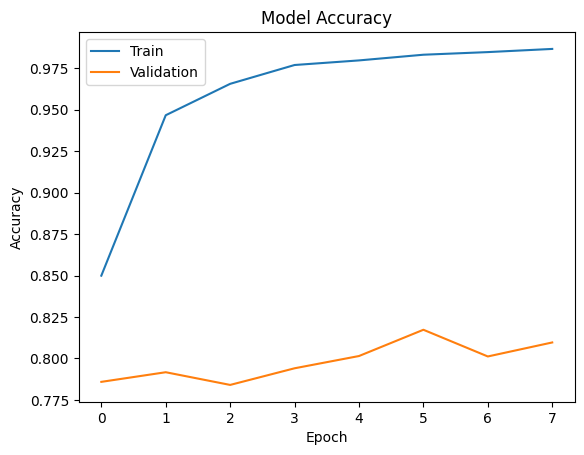

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.show()

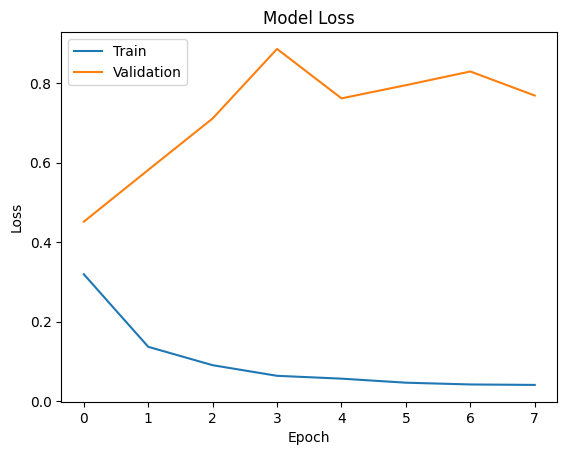

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.show()